<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/2_LM_Multiple_Regression_one_hot_encoding_Airfares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Multiple Regression and One-Hot Encoding: Airfares

Does **which airline leads a market** change its fares, once distance and competition are counted?
The airline is a text column, so the model cannot use it until we **one-hot encode** it.

Slides: W3.1, multiple regression, train/test split, one-hot encoding vs. dummy variables.

> **Data.** The 200 busiest U.S. domestic markets in 2019, read straight from the course GitHub repository.
> Source: Sabre Market Intelligence, licensed to Embry-Riddle.

## 1. Library and Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
routes = pd.read_csv('https://raw.githubusercontent.com/kjmobile/lb2/main/data/sabre_routes_2019.csv')
routes.head()

,airport_1,airport_2,distance_mi,passengers,avg_fare,lcc_share,hhi,top_airline
0,JFK,LAX,2470.0,3115042.0,349.29,0.321,0.269,DL
1,LGA,ORD,731.0,2600397.0,174.47,0.086,0.293,AA
2,LAX,SFO,337.0,2289910.0,104.55,0.203,0.212,AS
3,LAX,ORD,1741.0,1853120.0,187.84,0.146,0.332,UA
4,LAS,LAX,236.0,1831441.0,73.20,0.438,0.180,WN


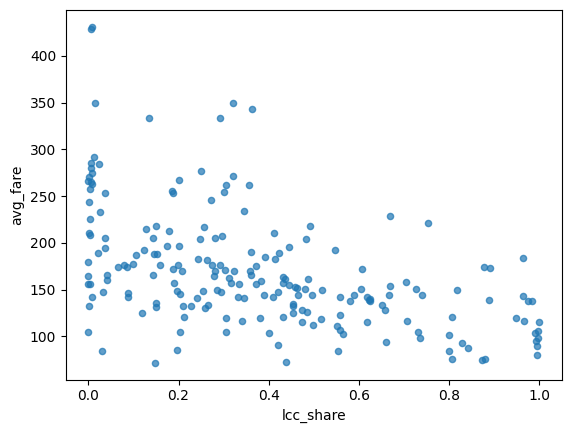

In [3]:
routes.plot(kind='scatter', x='lcc_share', y='avg_fare', s=20, alpha=.7)
plt.show()

| Column | Meaning |
|---|---|
| `distance_mi` | distance in miles |
| `lcc_share` | share of passengers on low-cost airlines |
| `hhi` | market concentration (1 = one airline carries everyone) |
| `top_airline` | code of the airline with the most passengers: AA American, DL Delta, UA United, WN Southwest, AS Alaska, B6 JetBlue, HA Hawaiian, NK Spirit |
| `avg_fare` | average base fare ($), what we predict |

**What is `hhi`?** The **Herfindahl–Hirschman Index**, the standard measure of market concentration.
Square each airline's share of the market's passengers, then add them up:

$$HHI = \sum_i s_i^2 \qquad (s_i = \text{airline } i\text{'s share of passengers})$$

| Market | Shares | HHI |
|---|---|---|
| One airline carries everyone | 1.0 | 1.0 |
| Two airlines, half each | 0.5, 0.5 | 0.25 + 0.25 = 0.5 |
| Four airlines, a quarter each | 0.25 each | 4 × 0.0625 = 0.25 |

Here shares are fractions, so HHI runs from 0 to 1. News reports and U.S. merger reviews put shares in percent,
so the same index runs from 0 to 10,000 (two airlines at half each = 5,000).

## 2. Check Data

In [4]:
data = routes[['distance_mi', 'lcc_share', 'hhi', 'top_airline', 'avg_fare']]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   distance_mi  200 non-null    float64
 1   lcc_share    200 non-null    float64
 2   hhi          200 non-null    float64
 3   top_airline  200 non-null    object 
 4   avg_fare     200 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.9+ KB


In [5]:
data['top_airline'].value_counts()

top_airline
WN    45
DL    44
AA    39
UA    35
AS    19
B6    10
HA     5
NK     3
Name: count, dtype: int64

`top_airline` is text (`object`). A regression model needs numbers.

## 3. Preprocessing

### 3.1 One-hot encoding

One new 0/1 column for each airline: 1 if that airline leads the market, 0 if not.

In [6]:
data_encoded = pd.get_dummies(data, columns=['top_airline'], dtype=int)
data_encoded.head(3)

,distance_mi,lcc_share,hhi,avg_fare,top_airline_AA,top_airline_AS,top_airline_B6,top_airline_DL,top_airline_HA,top_airline_NK,top_airline_UA,top_airline_WN
0,2470.0,0.321,0.269,349.29,0,0,0,1,0,0,0,0
1,731.0,0.086,0.293,174.47,1,0,0,0,0,0,0,0
2,337.0,0.203,0.212,104.55,0,1,0,0,0,0,0,0


In [7]:
data_encoded.columns

Index(['distance_mi', 'lcc_share', 'hhi', 'avg_fare', 'top_airline_AA',
       'top_airline_AS', 'top_airline_B6', 'top_airline_DL', 'top_airline_HA',
       'top_airline_NK', 'top_airline_UA', 'top_airline_WN'],
      dtype='object')

### 3.2 Inputs (X), target (y), and the train/test split

In [8]:
# Every column except the fare is an input
X = data_encoded.loc[:, data_encoded.columns != 'avg_fare']
y = data_encoded['avg_fare']

# How much of the data is used for training?
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print('train:', len(X_train), ' test:', len(X_test))

train: 160  test: 40


## 4. Modeling

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Note: here we only want good **predictions**, so we keep every airline column. To **interpret** the airline
coefficients, drop one airline column (a dummy variable): see section 7.

## 5. Prediction

In [10]:
pred = model.predict(X_test)
comparison = pd.DataFrame({'actual': y_test, 'pred': pred.round(0)})
comparison.head(10)

,actual,pred
18,115.35,113.0
170,144.57,121.0
107,197.11,224.0
98,90.05,70.0
177,212.54,244.0
182,158.49,152.0
5,141.66,158.0
146,176.51,216.0
12,349.48,325.0
152,333.96,273.0


## 6. Evaluating the Model

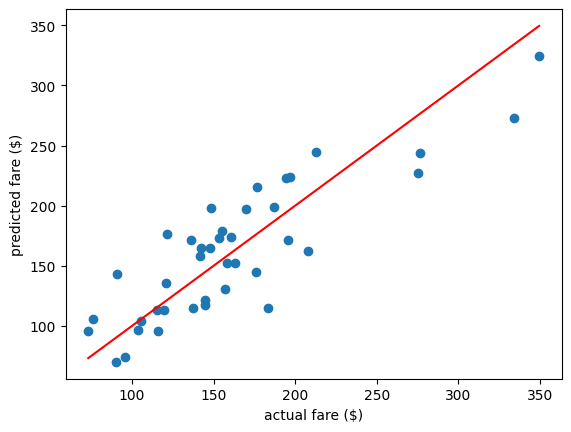

In [11]:
plt.scatter(y_test, pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')   # perfect predictions
plt.xlabel('actual fare ($)')
plt.ylabel('predicted fare ($)')
plt.show()

In [12]:
mse = mean_squared_error(y_test, pred)
print('MSE: ', round(mse, 1))
print('RMSE:', round(mse ** 0.5, 1), 'dollars')
print('R2 on train set:', round(model.score(X_train, y_train), 3))
print('R2 on test set: ', round(model.score(X_test, y_test), 3))

MSE:  957.7
RMSE: 30.9 dollars
R2 on train set: 0.817
R2 on test set:  0.744


### 6.1 Did the airline columns help?

Fit the same model **without** the airline columns and compare the test R².

In [13]:
numeric = ['distance_mi', 'lcc_share', 'hhi']
model_num = LinearRegression()
model_num.fit(X_train[numeric], y_train)

print('test R2, numbers only:       ', round(model_num.score(X_test[numeric], y_test), 3))
print('test R2, plus the top airline:', round(model.score(X_test, y_test), 3))

test R2, numbers only:        0.697
test R2, plus the top airline: 0.744


### Your turn

One-hot encode `top_airline`, then fit a linear regression on the training set and print its test R².

Fill in the blanks:

```python
data_encoded = pd.get_dummies(data, columns=['___________'], dtype=int)
X = data_encoded.loc[:, data_encoded.columns != '________']
y = data_encoded['avg_fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = ________________()
model.fit(_______, _______)
print(model.score(______, ______))
```

<details><summary>Show answer</summary>

```python
data_encoded = pd.get_dummies(data, columns=['top_airline'], dtype=int)
X = data_encoded.loc[:, data_encoded.columns != 'avg_fare']
y = data_encoded['avg_fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))
```
</details>

In [14]:
# Write your code here

## 7. Reading the Airline Effect: Dummy Variables

Drop one airline column so it becomes the **reference**. `drop_first=True` drops the first in alphabetical
order: **AA (American)**. Each remaining airline coefficient then means: *dollars above or below an
American-led market with the same distance, low-cost share and concentration.*

In [15]:
data_dummy = pd.get_dummies(data, columns=['top_airline'], dtype=int, drop_first=True)
X_dummy = data_dummy.loc[:, data_dummy.columns != 'avg_fare']

model_dummy = LinearRegression()
model_dummy.fit(X_dummy, data_dummy['avg_fare'])

pd.Series(model_dummy.coef_, index=X_dummy.columns).round(1)

distance_mi        0.1
lcc_share        -82.1
hhi               62.1
top_airline_AS    -2.6
top_airline_B6    29.3
top_airline_DL    31.2
top_airline_HA   -24.2
top_airline_NK    10.9
top_airline_UA    40.2
top_airline_WN    27.0
dtype: float64

**Read it:** a market led by United (`top_airline_UA`) averages about $40 more than an American-led market
with the same distance and competition. Why might hub carriers like United and Delta charge more?

---
# Challenge

> Create a new model named `model_1` with **all** airline columns (from section 3) and **no intercept**:
>
> ```python
> model_1 = LinearRegression(fit_intercept=False)
> model_1.fit(X_train, y_train)
> ```
>
> Compare `model_1.coef_` with `model.coef_`.

- Which coefficients change the most, especially the airline columns?
- Why? (Hint: with all airline columns plus an intercept, the airline columns always add up to 1, the same
  information as the intercept. This is **multicollinearity**. What does each airline coefficient mean when
  there is no intercept?)

In [16]:
# Your answer